# ESS and Weight Diagnostics

This notebook studies **ESS monitoring and weight analysis** for a Bootstrap Particle Filter
applied to a Stochastic Volatility (SV) model. We cover:

- Effective Sample Size: $\mathrm{ESS}_t = 1 / \sum_i (w_t^{(i)})^2$
- Maximum weight and Shannon entropy $H_t = -\sum_i w_t^{(i)} \log w_t^{(i)}$
- Degeneracy detection (ESS < N/10)
- Role of the proposal distribution: Bootstrap PF vs Auxiliary PF
- ESS response to extreme observations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.core.config import PFConfig
from particlefilterbox.filters.bootstrap import BootstrapPF
from particlefilterbox.filters.auxiliary import AuxiliaryPF
from particlefilterbox.diagnostics import ESSMonitor, WeightAnalysis

plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['figure.dpi'] = 100
np.set_printoptions(suppress=True, precision=4)
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df = pd.read_csv(data_path)
h_true = df['h_true'].values
y_obs = df['y_obs'].values
T = len(df)
print(f'Loaded {T} observations')
df.head()

Loaded 1000 observations


,t,h_true,y_obs
0,0,-0.811984,-0.692957
1,1,-0.705057,0.661131
2,2,-1.006561,-0.787225
3,3,-0.987188,-0.193044
4,4,-0.990092,-0.519967


## Model and Filter Setup

Basic SV model (Kim, Shephard & Chib, 1998):

$$h_t = \mu + \phi(h_{t-1} - \mu) + \sigma \eta_t, \qquad y_t = \exp(h_t/2)\,\varepsilon_t$$

We run a Bootstrap PF with $N=1000$ and record the **full normalized weight history**
via the per-step `filter_step` API so we can compute entropy, maximum weight and
weight histograms post-hoc.


In [3]:
class SVModel(ParticleFilterModel):
    k_states = 1
    k_obs = 1

    def __init__(self, mu: float = -1.0, phi: float = 0.97, sigma: float = 0.15) -> None:
        self.mu = mu
        self.phi = phi
        self.sigma = sigma

    @property
    def params(self) -> dict[str, float]:
        return {'mu': self.mu, 'phi': self.phi, 'sigma': self.sigma}

    def initial_distribution(self, n_particles, rng):
        std = self.sigma / np.sqrt(1.0 - self.phi**2)
        return rng.normal(self.mu, std, size=(n_particles, 1))

    def transition(self, particles, t, rng):
        h = particles[:, 0]
        return (self.mu + self.phi * (h - self.mu)
                + self.sigma * rng.standard_normal(len(h))).reshape(-1, 1)

    def log_observation_likelihood(self, particles, y_t, t):
        h = particles[:, 0]
        vol = np.exp(h / 2.0)
        return -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_t[0] / vol) ** 2


def run_pf_with_weight_history(pf, y):
    rng = pf._get_rng()
    cloud = pf.initialize(rng)
    T = len(y)
    N = pf.n_particles
    weights = np.zeros((T, N))
    ess = np.zeros(T)
    means = np.zeros(T)
    ll_increments = np.zeros(T)
    for t in range(T):
        y_t = np.atleast_1d(y[t])
        cloud, ll_t = pf.filter_step(cloud, y_t, t)
        weights[t] = cloud.normalized_weights
        ess[t] = cloud.ess
        means[t] = cloud.weighted_mean()[0]
        ll_increments[t] = ll_t
    return {
        'weights': weights,
        'ess': ess,
        'means': means,
        'll_increments': ll_increments,
        'final_cloud': cloud,
    }


N = 1000
model = SVModel()
cfg = PFConfig(n_particles=N, resampling='systematic', ess_threshold=0.5, seed=42)
bpf = BootstrapPF(model, cfg)
bpf_out = run_pf_with_weight_history(bpf, y_obs)
print(f'Mean ESS = {bpf_out["ess"].mean():.1f} / {N}')
print(f'Min  ESS = {bpf_out["ess"].min():.1f}')
print(f'Log-lik  = {bpf_out["ll_increments"].sum():.2f}')

Mean ESS = 765.3 / 1000
Min  ESS = 500.5
Log-lik  = -812.93


## 1. ESS over time with resampling threshold

The dashed red line shows the resampling threshold $N/2$; the dotted orange line marks
the degeneracy threshold $N/10$. Whenever ESS drops below $N/2$ the filter triggered
systematic resampling, which is why the trace repeatedly bounces back up.


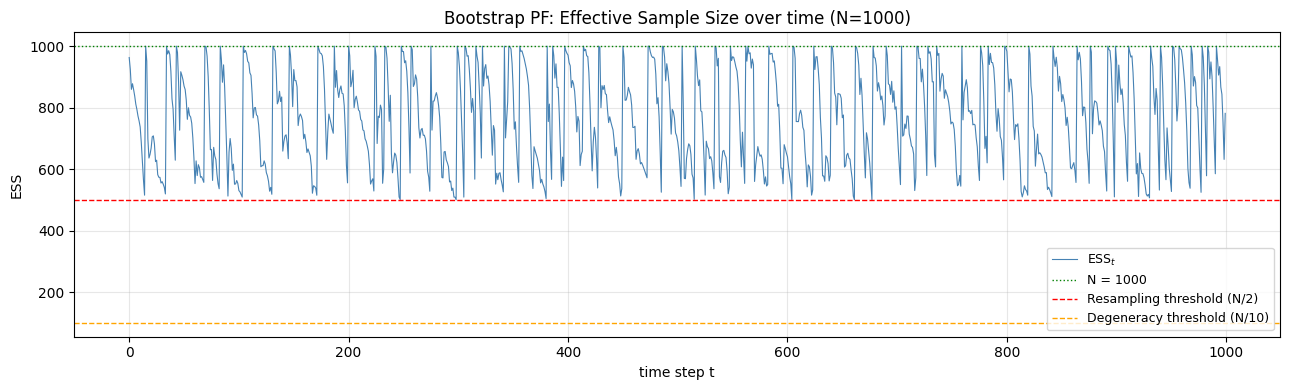

ESS < N/2  in 0.0% of steps
ESS < N/10 in 0.0% of steps (severe degeneracy)


In [4]:
ess = bpf_out['ess']
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ess, lw=0.8, color='steelblue', label='ESS$_t$')
ax.axhline(N, color='green', ls=':', lw=1, label=f'N = {N}')
ax.axhline(N * 0.5, color='red', ls='--', lw=1, label='Resampling threshold (N/2)')
ax.axhline(N * 0.1, color='orange', ls='--', lw=1, label='Degeneracy threshold (N/10)')
ax.set_xlabel('time step t')
ax.set_ylabel('ESS')
ax.set_title(f'Bootstrap PF: Effective Sample Size over time (N={N})')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'ESS < N/2  in {(ess < N/2).mean():.1%} of steps')
print(f'ESS < N/10 in {(ess < N/10).mean():.1%} of steps (severe degeneracy)')

## 2. Maximum weight over time

When a single particle holds most of the mass, $\max_i w_t^{(i)} \to 1$.


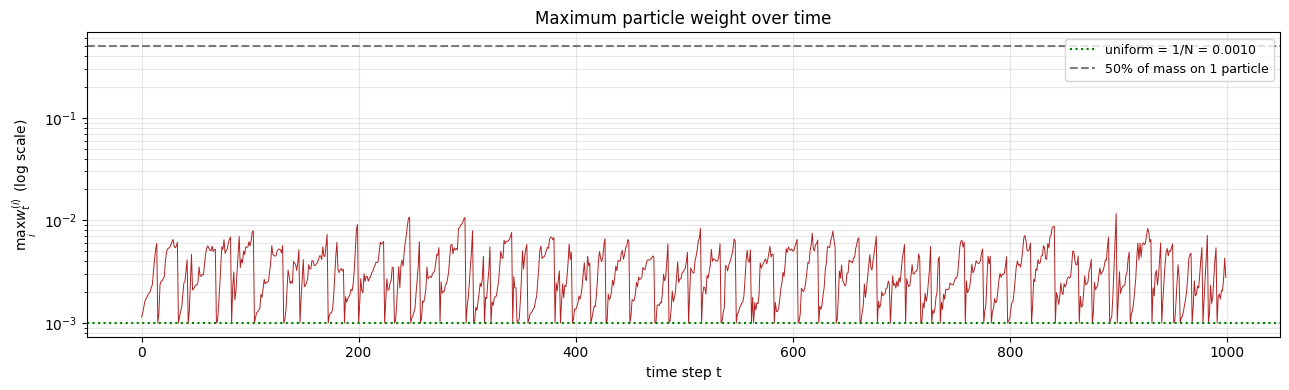

Peak max weight = 0.0116 at t=898


In [5]:
w_hist = bpf_out['weights']
max_w = w_hist.max(axis=1)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(max_w, color='firebrick', lw=0.7)
ax.axhline(1.0 / N, color='green', ls=':', label=f'uniform = 1/N = {1/N:.4f}')
ax.axhline(0.5, color='black', ls='--', alpha=0.5, label='50% of mass on 1 particle')
ax.set_yscale('log')
ax.set_xlabel('time step t')
ax.set_ylabel(r'$\max_i w_t^{(i)}$ (log scale)')
ax.set_title('Maximum particle weight over time')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()
print(f'Peak max weight = {max_w.max():.4f} at t={int(max_w.argmax())}')

## 3. Weight entropy and weight diversity

Shannon entropy $H_t = -\sum_i w_t^{(i)} \log w_t^{(i)}$ equals $\log N$ for uniform
weights and collapses to 0 when a single particle dominates.


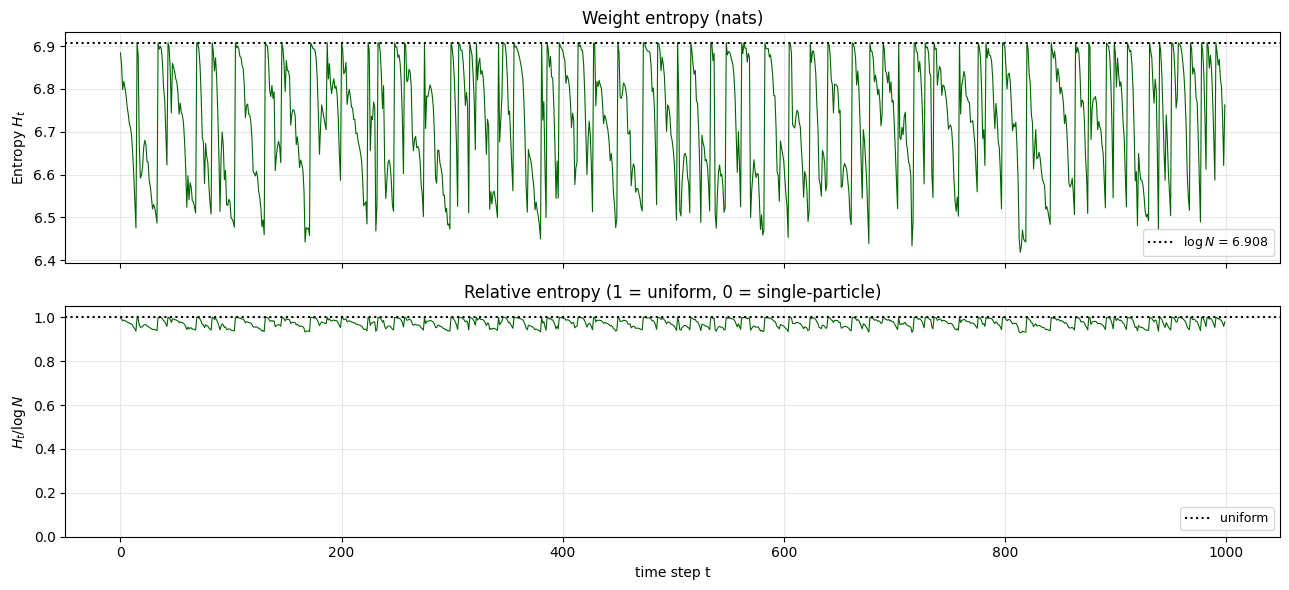

Relative entropy: mean = 0.974, min = 0.929


In [6]:
# Compute entropy robustly (mask zero weights)
def weight_entropy(w):
    mask = w > 0
    return -np.sum(w[mask] * np.log(w[mask]))

entropy_t = np.array([weight_entropy(w_hist[t]) for t in range(T)])
rel_entropy_t = entropy_t / np.log(N)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax = axes[0]
ax.plot(entropy_t, color='darkgreen', lw=0.8)
ax.axhline(np.log(N), color='black', ls=':', label=f'$\\log N$ = {np.log(N):.3f}')
ax.set_ylabel('Entropy $H_t$')
ax.set_title('Weight entropy (nats)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rel_entropy_t, color='darkgreen', lw=0.8)
ax.axhline(1.0, color='black', ls=':', label='uniform')
ax.set_xlabel('time step t')
ax.set_ylabel('$H_t / \\log N$')
ax.set_ylim(0, 1.05)
ax.set_title('Relative entropy (1 = uniform, 0 = single-particle)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Relative entropy: mean = {rel_entropy_t.mean():.3f}, min = {rel_entropy_t.min():.3f}')

## 4. Weight histograms at high-ESS vs low-ESS steps

The left panel picks a time step where ESS is close to $N$ (weights near-uniform);
the right panel picks the step where ESS is lowest (most degenerate).


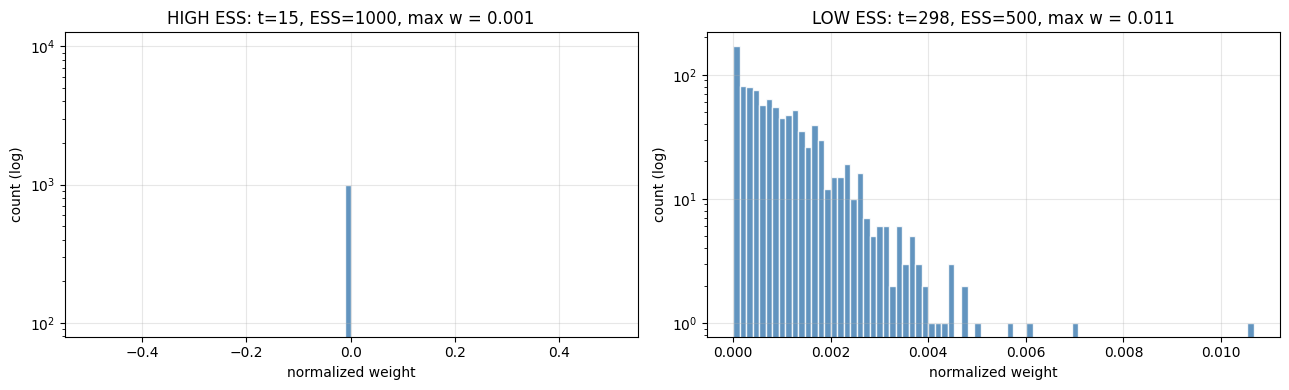

High-ESS step t=15: ESS=1000, max w = 0.0010
Low-ESS  step t=298: ESS=500, max w = 0.0107


In [7]:
t_high = int(np.argmax(ess))
t_low  = int(np.argmin(ess))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, t_idx, tag in [(axes[0], t_high, 'HIGH'), (axes[1], t_low, 'LOW')]:
    w = w_hist[t_idx]
    ax.hist(w, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_yscale('log')
    ax.set_xlabel('normalized weight')
    ax.set_ylabel('count (log)')
    ax.set_title(f'{tag} ESS: t={t_idx}, ESS={ess[t_idx]:.0f}, max w = {w.max():.3f}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'High-ESS step t={t_high}: ESS={ess[t_high]:.0f}, max w = {w_hist[t_high].max():.4f}')
print(f'Low-ESS  step t={t_low}: ESS={ess[t_low]:.0f}, max w = {w_hist[t_low].max():.4f}')

## 5. Bootstrap PF vs Auxiliary PF: impact of the proposal

The Auxiliary PF (Pitt & Shephard, 1999) pre-selects ancestors using the observation
likelihood evaluated at transition means, which tends to raise ESS whenever the
transition is weakly informative about $y_t$.


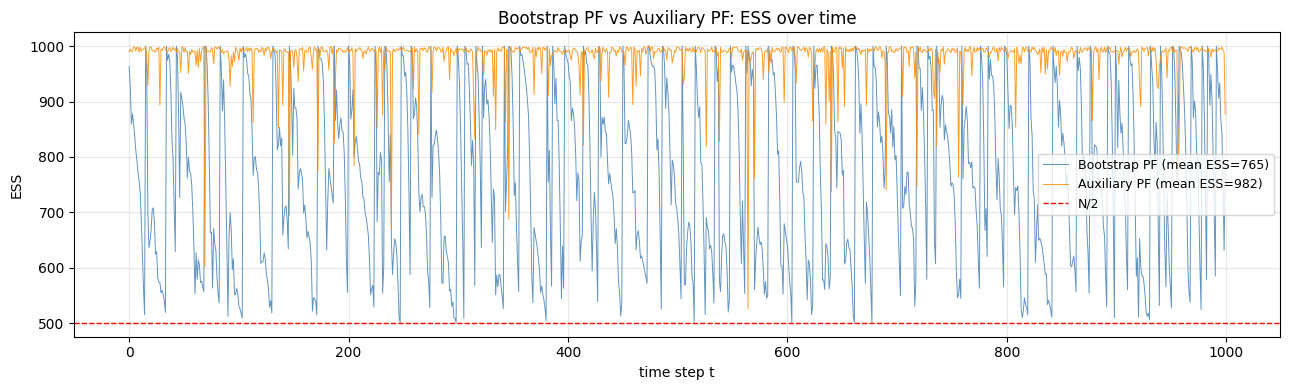

BPF log-lik = -812.93
APF log-lik = -0.37


In [8]:
cfg_apf = PFConfig(n_particles=N, resampling='systematic', ess_threshold=0.5, seed=42)
apf = AuxiliaryPF(SVModel(), cfg_apf)
apf_out = run_pf_with_weight_history(apf, y_obs)

ess_bpf = bpf_out['ess']
ess_apf = apf_out['ess']

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ess_bpf, lw=0.7, color='steelblue', alpha=0.85, label=f'Bootstrap PF (mean ESS={ess_bpf.mean():.0f})')
ax.plot(ess_apf, lw=0.7, color='darkorange', alpha=0.85, label=f'Auxiliary PF (mean ESS={ess_apf.mean():.0f})')
ax.axhline(N * 0.5, color='red', ls='--', lw=1, label='N/2')
ax.set_xlabel('time step t')
ax.set_ylabel('ESS')
ax.set_title('Bootstrap PF vs Auxiliary PF: ESS over time')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'BPF log-lik = {bpf_out["ll_increments"].sum():.2f}')
print(f'APF log-lik = {apf_out["ll_increments"].sum():.2f}')

## 6. ESS vs |y_t|: degeneracy is driven by extreme observations

For the SV model, very large $|y_t|$ forces only high-volatility particles to survive,
so ESS is expected to fall when $|y_t|$ is large. The scatter plot confirms a clear
negative relationship.


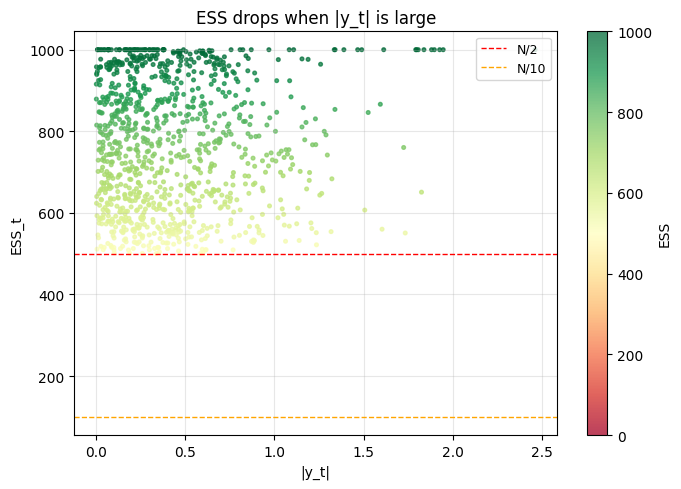

Pearson corr(|y_t|, ESS_t) = +0.048


In [9]:
abs_y = np.abs(y_obs)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(abs_y, ess_bpf, s=7, c=ess_bpf, cmap='RdYlGn', alpha=0.75,
                vmin=0, vmax=N)
plt.colorbar(sc, ax=ax, label='ESS')
ax.axhline(N * 0.5, color='red', ls='--', lw=1, label='N/2')
ax.axhline(N * 0.1, color='orange', ls='--', lw=1, label='N/10')
ax.set_xlabel('|y_t|')
ax.set_ylabel('ESS_t')
ax.set_title('ESS drops when |y_t| is large')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify the relationship
corr = np.corrcoef(abs_y, ess_bpf)[0, 1]
print(f'Pearson corr(|y_t|, ESS_t) = {corr:+.3f}')

## 7. Summary statistics of diagnostics

All statistics are taken over the $T$ time steps.


In [10]:
summary = pd.DataFrame({
    'Bootstrap PF': [
        ess_bpf.mean(), ess_bpf.min(), np.median(ess_bpf),
        (ess_bpf < N/2).mean(), (ess_bpf < N/10).mean(),
        max_w.mean(), max_w.max(),
        entropy_t.mean(), rel_entropy_t.min(),
        bpf_out['ll_increments'].sum(),
    ],
    'Auxiliary PF': [
        ess_apf.mean(), ess_apf.min(), np.median(ess_apf),
        (ess_apf < N/2).mean(), (ess_apf < N/10).mean(),
        apf_out['weights'].max(axis=1).mean(),
        apf_out['weights'].max(axis=1).max(),
        np.mean([weight_entropy(apf_out['weights'][t]) for t in range(T)]),
        np.min([weight_entropy(apf_out['weights'][t]) for t in range(T)]) / np.log(N),
        apf_out['ll_increments'].sum(),
    ],
}, index=[
    'mean ESS', 'min ESS', 'median ESS',
    'fraction ESS < N/2', 'fraction ESS < N/10',
    'mean max-weight', 'peak max-weight',
    'mean entropy (nats)', 'min relative entropy',
    'log p(y_{1:T})',
])
summary = summary.round(4)
summary

,Bootstrap PF,Auxiliary PF
mean ESS,765.2578,982.0313
min ESS,500.4863,525.8544
median ESS,762.8493,991.8974
fraction ESS < N/2,0.0000,0.0000
fraction ESS < N/10,0.0000,0.0000
mean max-weight,0.0033,0.0017
peak max-weight,0.0116,0.0137
mean entropy (nats),6.7250,6.8985
min relative entropy,0.9292,0.9575
log p(y_{1:T}),-812.9250,-0.3674


## 8. Weight heatmap: top 50 particles over time

For each time step we pick the 50 particles with the largest normalized weight and
plot their weights on a log scale. Bright stripes mark time steps where weight is
concentrated on a handful of particles.


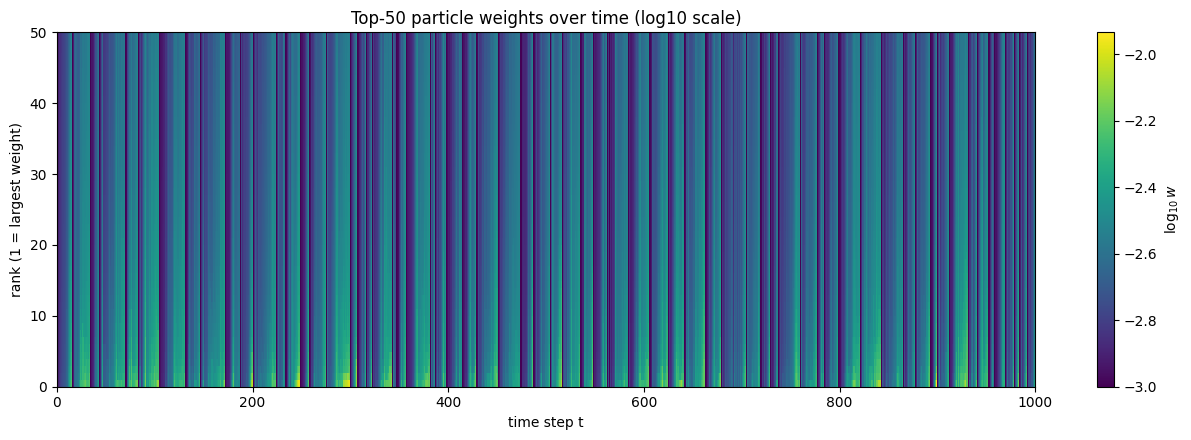

In [11]:
TOP_K = 50
# For each time step, sort weights descending and keep the top-K
top = np.sort(w_hist, axis=1)[:, -TOP_K:][:, ::-1]  # (T, TOP_K), descending
top_log = np.log10(np.clip(top, 1e-12, None))

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(top_log.T, aspect='auto', origin='lower',
               cmap='viridis', interpolation='nearest',
               extent=[0, T, 0, TOP_K])
ax.set_xlabel('time step t')
ax.set_ylabel('rank (1 = largest weight)')
ax.set_title(f'Top-{TOP_K} particle weights over time (log10 scale)')
plt.colorbar(im, ax=ax, label=r'$\log_{10} w$')
plt.tight_layout()
plt.show()

## 9. Guidelines

**When does resampling help?**
- Resample whenever ESS drops below $\alpha N$ with $\alpha \in [0.3, 0.5]$. The default
  $\alpha = 0.5$ used here is a robust choice.
- Resampling too often injects Monte Carlo noise; resampling too rarely lets weights
  degenerate. Adaptive ESS-triggered resampling is the standard compromise.

**Choosing N**
- For the SV model with mild persistence the Bootstrap PF runs healthy with $N \sim 10^3$.
  If you observe $\mathrm{ESS} < N/10$ at any step, increase $N$ or switch to a better
  proposal (Auxiliary PF, Locally Optimal PF).
- Extreme observations ($|y_t|$ large) are the main driver of low ESS: monitor
  $\mathrm{ESS}_t$ vs $|y_t|$ to decide where to refine the proposal.

**Diagnostic triad**
- Always inspect three signals jointly: ESS trace, max-weight trace, and weight entropy.
  Agreement across the three is a strong indicator that the approximation is healthy.
